# JSON based persistent exploration trial

*We arrived at the conclusion that we need to store our explorations in a json data structure.*

## Koen's code

Let's start with a bOxEdit stream and store it in a JSON file.  

Ready with downloading 16 selected remote files to local cache: /home/frank/.cache/fairdatanow                                                                      


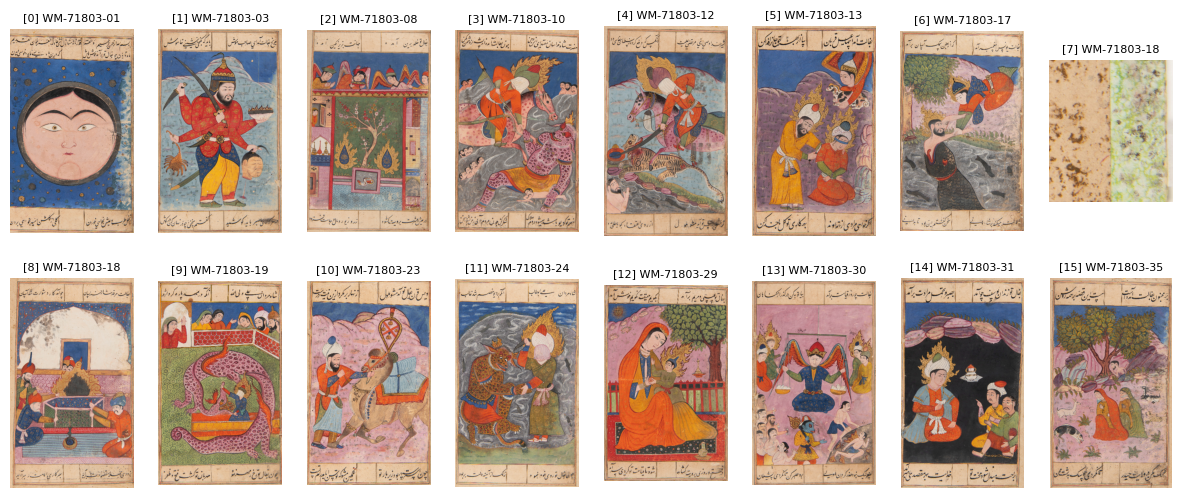

In [1]:
#|code-fold: true 
from fairdatanow import DataViewer
import matplotlib.pyplot as plt 
import os
import numpy as np 

import maxrf4u as mx
import re

#|code-fold: true 
configuration = {
    'url': "https://laboppad.nl/falnama-project", 
    'user':    os.getenv('NC_AUTH_USER'),
    'password': os.getenv('NC_AUTH_PASS')
}

filters = {'extensions': ['.datastack']} 

dv = DataViewer(configuration, **filters)
datastack_files = dv.download_filtered() 

imvis_list = []
extent_list = []
for datastack_file in datastack_files: 
    ds = mx.DataStack(datastack_file)
    im = ds.read('imvis_reg')
    extent = ds.read('imvis_extent')
    imvis_list.append(im)
    extent_list.append(extent)

object_nums = [re.sub(r'.*(WM-71803-\d\d).*', r'\1', dsf) for dsf in datastack_files]

fig, axs = plt.subplots(ncols=8, nrows=2, figsize=[15, 6])
axs = axs.flatten()
for i, [im, ax, extent] in enumerate(zip(imvis_list, axs, extent_list)): 
    ax.imshow(im, extent=extent)
    ax.set_title(f'[{i}] {object_nums[i]}', fontsize=8)
    ax.axis('off')

In [2]:
n = 15
datastack_file = datastack_files[n]
ds = mx.DataStack(datastack_file)

object_num = object_nums[n]

#cube = ds.read('maxrf_cube', compute=False)
imvis_highres = ds.read('imvis_reg_highres')
imvis = ds.read('imvis_reg')
extent = ds.read('imvis_extent')

h, w, d = imvis.shape

## A dashboard

Now run the FUNCTIONS section below and take a look at the dashboard:

In [4]:
dashboard

Row
    [0] HoloViews(DynamicMap, sizing_mode='fixed')
    [1] Tabs
        [0] Markdown(str, name='red')
        [1] Markdown(str, name='green')

The question is now if we can extend the visualization with the ROI's dynamically loaded? A very simple extension would be to add dynamic labels to the ROI's...

In [24]:
from holoviews.streams import Stream
import param 

In [27]:
ROI_Labels = Stream.define('ROI_Labels', xy_list=param.List(doc='ROI list'), label_list=param.List(doc='Label list'))

In [28]:
roi_labels = ROI_Labels(xy_list=[1, 2, 3], label_list=['a', 'b', 'c'])

In [31]:
roi_labels.label_list

['A']

In [30]:
roi_labels.event(label_list=['A'])

In [ ]:
hv.DynamicMap()

## Parse JSON to slice cube

In [7]:
rgb2 = hv.RGB(imvis, bounds=[-0.5,h-0.5,w-0.5,-0.5]).opts(active_tools=[], aspect='equal', frame_width=700)

In [8]:
rgb2

:RGB   [x,y]   (R,G,B)

As a first step we need to convert these floats into integer slices... 

In [ ]:
with open('file.json', 'r') as fh:
    boxes_data = json.load(fh)


x0 = np.clip(np.round(boxes_data['x0']), a_min=0, a_max=w-1).astype(int)
x1 = np.clip(np.round(boxes_data['x1']), a_min=0, a_max=w-1).astype(int)
y0 = np.clip(np.round(boxes_data['y0']), a_min=0, a_max=h-1).astype(int)
y1 = np.clip(np.round(boxes_data['y1']), a_min=0, a_max=h-1).astype(int)

In [140]:
corner_pixs = hv.Scatter((x0, y0)).opts(color='white')

Ok, we are now ready to compute the cube slices...

In [142]:
cube = ds.read('maxrf_cube', compute=False) 

In [145]:
roi_cubes = [cube[i:j+1, k:l+1].compute() for i, j, k, l in zip(y0, y1, x0, x1)]

In [147]:
max_map0 = roi_cubes[0].max(axis=2)

In [149]:
roi0_im = hv.Image(max_map0).opts(aspect='equal', frame_width=700)

In [156]:
roi0_rgb = rgb2[100:200, 50:300, 'G'].opts(alpha=0.2) 

In [ ]:
def get_roi_cubes(datastack_file, json_file='file.json'): 
    '''For now return lazy dask array roi cubes.''' 

    # read cube 
    ds = DataStack(datastack_file) 
    cube = ds.read('maxrf_cube', compute=False)

    # read roi boxes data  
    with open(json_file, 'r') as fh: 
        boxes_data = json.load(fh)
                
    x0 = np.clip(np.round(boxes_data['x0']), a_min=0, a_max=w-1).astype(int)
    x1 = np.clip(np.round(boxes_data['x1']), a_min=0, a_max=w-1).astype(int)
    y0 = np.clip(np.round(boxes_data['y0']), a_min=0, a_max=h-1).astype(int)
    y1 = np.clip(np.round(boxes_data['y1']), a_min=0, a_max=h-1).astype(int)

        

## FUNCTIONS 

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
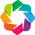

In [3]:
# Koen's clever update tabs code 

import holoviews as hv
from holoviews import opts, streams
from holoviews.operation.datashader import rasterize
import json
import panel as pn

from maxrf4u import DataStack 

def update_tabs():
    tabs.clear()
    with open('file.json') as f:
        d = json.load(f)
        if d['fill_color']:
            for i, roi in enumerate(d['fill_color']):
                tabs.append(pn.pane.Markdown(f"x0:{d['x0'][i]}, y0:{d['y0'][i]}, x1:{d['x1'][i]}, y1:{d['y1'][i]}", name=roi))
                
def on_box_change(data):
    if data:
        with open("file.json", "w") as f:
            json.dump(data, f)
        update_tabs()
        
def get_rectangles(json_file): 
    '''Load rectangles from json.'''

    # read roi boxes data  
    with open(json_file, 'r') as fh: 
        boxes_dict = json.load(fh) 

    # convert dictionary into a list of rectangle tuples
    rectangles = [(x0, y0, x1, y1) for x0, y0, x1, y1 in zip(boxes_dict['x0'], boxes_dict['y0'], boxes_dict['x1'], boxes_dict['y1'])]
                                                                  
    return rectangles
    

hv.extension('bokeh') 

rectangles = get_rectangles('file.json') 
boxes = hv.Rectangles(rectangles).opts(fill_alpha=0.3)
box_stream = streams.BoxEdit(source=boxes, num_objects=3, styles={'fill_color': ['red', 'green', 'blue']})

rgb_low = hv.RGB(imvis, bounds=[-0.5,h-0.5,w-0.5,-0.5]).opts(aspect='equal', frame_width=300) 
rgb = rasterize(hv.RGB(imvis_highres, bounds=[-0.5,h-0.5,w-0.5,-0.5])).opts(active_tools=['box_edit'], aspect='equal', frame_width=300)
box_stream.add_subscriber(on_box_change) 

main = rgb * boxes
tabs = pn.Tabs(dynamic=False)

update_tabs()

dashboard = pn.Row(main, tabs) 

In [57]:
dashboard 

Row
    [0] HoloViews(DynamicMap, sizing_mode='fixed')
    [1] Tabs
        [0] Markdown(str, name='red')
        [1] Markdown(str, name='green')

In [18]:
labels.param.values().items()

dict_items([('cdims', {}), ('datatype', ['dataframe', 'dictionary', 'grid', 'xarray', 'multitabular', 'spatialpandas', 'dask_spatialpandas', 'dask', 'cuDF', 'array', 'ibis']), ('extents', (None, None, None, None)), ('group', 'Labels'), ('kdims', [Dimension('x'), Dimension('y')]), ('label', ''), ('name', 'Labels01630'), ('vdims', [Dimension('Label')])])

In [19]:
labels.data

,x,y,Label
0,94.337422,350.810517,0
1,175.620000,427.242248,1
2,182.760000,371.259622,2


In [14]:
labels = hv.Labels([(x, y, i)  for i, (x, y) in enumerate(zip(box_stream.data['x0'], box_stream.data['y0']))])

In [20]:
boxes * labels

:Overlay
   .Rectangles.I :Rectangles   [x0,y0,x1,y1]
   .Labels.I     :Labels   [x,y]   (Label)

In [47]:
#dashboard.save('export_test.html', embed=True)

## Slice maps etcetera 

In [6]:
def get_roi_cubes(datastack_file, json_file='file.json'): 
    '''For now return lazy dask array roi cubes.''' 

    # read cube 
    ds = DataStack(datastack_file) 
    cube = ds.read('maxrf_cube', compute=False)

    # read roi boxes data  
    with open(json_file, 'r') as fh: 
        boxes_data = json.load(fh)
                
    x0 = np.clip(np.round(boxes_data['x0']), a_min=0, a_max=w-1).astype(int)
    x1 = np.clip(np.round(boxes_data['x1']), a_min=0, a_max=w-1).astype(int)
    y0 = np.clip(np.round(boxes_data['y0']), a_min=0, a_max=h-1).astype(int)
    y1 = np.clip(np.round(boxes_data['y1']), a_min=0, a_max=h-1).astype(int)

        